In [1]:
import pandas as pd
import numpy as np
import sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# =========================
# 1. Load Dataset
# =========================
df = pd.read_csv(r"C:\Users\kajal\Downloads\nasa.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(r'[^A-Za-z0-9]+', '_', regex=True)

print(df.columns)

Index(['Unnamed_0_1', 'Unnamed_0', 'Company_Name', 'Location', 'Datum',
       'Detail', 'Status_Rocket', 'Rocket_Cost_of_the_mission_in_million',
       'Status_Mission', 'Rocket_Fuel', 'Environment_Impact'],
      dtype='str')


In [2]:
df.rename(columns={
    'Rocket_Cost_of_the_mission_in_million': 'Cost'
}, inplace=True)

In [3]:
print(df.columns)

Index(['Unnamed_0_1', 'Unnamed_0', 'Company_Name', 'Location', 'Datum',
       'Detail', 'Status_Rocket', 'Cost', 'Status_Mission', 'Rocket_Fuel',
       'Environment_Impact'],
      dtype='str')


 2. Remove Null Cost Rows

In [4]:
df["Cost"] = pd.to_numeric(df["Cost"], errors="coerce")

df = df.dropna(subset=["Cost"])

print("After removing null cost rows:", df.shape)

After removing null cost rows: (949, 11)


After removing null cost rows: (949, 11)


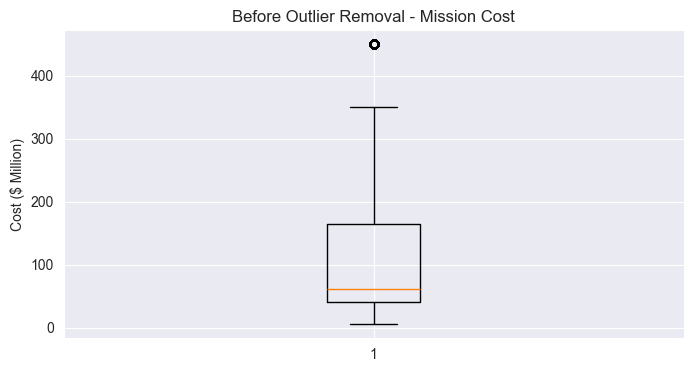

After outlier removal: (813, 11)


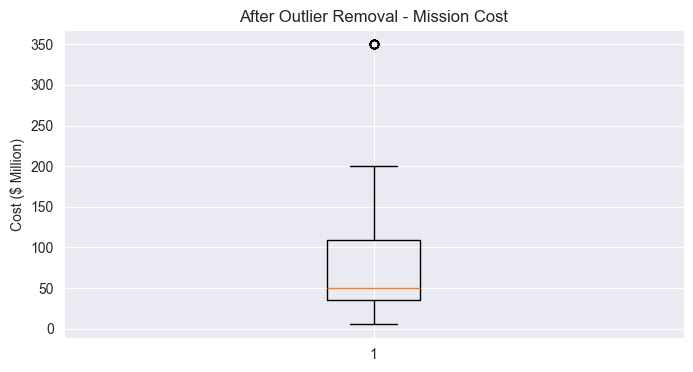

In [5]:
# =========================
# 2. Remove Null Cost Rows
# =========================

df["Cost"] = pd.to_numeric(df["Cost"], errors="coerce")

df = df.dropna(subset=["Cost"])

print("After removing null cost rows:", df.shape)

# =========================
# 3. Outlier Detection and Removal
# =========================

import matplotlib.pyplot as plt

# Before Outlier Removal
plt.figure(figsize=(8,4))
plt.boxplot(df["Cost"])
plt.title("Before Outlier Removal - Mission Cost")
plt.ylabel("Cost ($ Million)")
plt.show()

# IQR Method
Q1 = df["Cost"].quantile(0.25)
Q3 = df["Cost"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove Outliers
df = df[
    (df["Cost"] >= lower_limit) &
    (df["Cost"] <= upper_limit)
]

print("After outlier removal:", df.shape)

# After Outlier Removal
plt.figure(figsize=(8,4))
plt.boxplot(df["Cost"])
plt.title("After Outlier Removal - Mission Cost")
plt.ylabel("Cost ($ Million)")
plt.show()

 3. Fill Rocket Fuel Based on Similar Rocket

In [6]:
# Extract rocket name
df["Rocket_Name"] = df["Detail"].str.split("|").str[0].str.strip()

# Rule-based fuel mapping
def assign_fuel(row):
    fuel = row["Rocket_Fuel"]
    rocket = str(row["Rocket_Name"]).lower()

    if pd.notna(fuel) and fuel != "Unknown":
        return fuel

    if "falcon" in rocket:
        return "RP-1 + LOX"
    elif "starship" in rocket:
        return "Liquid Methane + LOX"
    elif "atlas v" in rocket:
        return "RP-1 + LOX / Liquid Hydrogen + LOX"
    elif "delta iv" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "ariane 5" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "soyuz" in rocket:
        return "RP-1 + LOX"
    elif "proton" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    elif "long march" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    elif "pslv" in rocket:
        return "Solid + Liquid Fuel"
    elif "gslv" in rocket:
        return "Solid + Liquid + Cryogenic Fuel"
    elif "electron" in rocket:
        return "RP-1 + LOX"
    elif "vega" in rocket:
        return "Solid Rocket Fuel"
    elif "h-iia" in rocket or "h-iib" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "minotaur" in rocket:
        return "Solid Rocket Fuel"
    elif "pegasus" in rocket:
        return "Solid Rocket Fuel"
    elif "new shepard" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "rokot" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    elif "zenit" in rocket:
        return "RP-1 + LOX"
    elif "dnepr" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    else:
        return "RP-1 + LOX"   # final fallback

In [7]:
df["Rocket_Fuel"] = df.apply(assign_fuel, axis=1)

4. Fill Environment Impact Based on Rocket Fuel

In [8]:
def fuel_to_environment(fuel):
    fuel = str(fuel).lower()

    # LOW impact fuels
    if ("liquid hydrogen" in fuel or "lh2" in fuel or
        "methane" in fuel):
        return "Low"

    # MEDIUM impact fuels
    elif ("rp-1" in fuel or "kerosene" in fuel or
          "lox" in fuel):
        return "Medium"

    # HIGH impact fuels (toxic)
    elif ("udmh" in fuel or "hydrazine" in fuel or
          "n2o4" in fuel or "nitrogen tetroxide" in fuel or
          "hypergolic" in fuel):
        return "High"

    # SOLID fuels → High pollution
    elif "solid" in fuel:
        return "High"

    # Default
    else:
        return "Medium"



In [9]:
df["Environment_Impact"] = df["Environment_Impact"].fillna(
    df["Rocket_Fuel"].apply(fuel_to_environment)
)


In [10]:
print("Missing values:")
print(df[["Rocket_Fuel", "Environment_Impact"]].isnull().sum())

print("\nUnknown fuel count:")
print((df["Rocket_Fuel"] == "Unknown").sum())

print("\nSample filled data:")
print(df[["Detail", "Rocket_Name", "Rocket_Fuel", "Environment_Impact"]].head(20))

Missing values:
Rocket_Fuel           0
Environment_Impact    0
dtype: int64

Unknown fuel count:
0

Sample filled data:
                                               Detail       Rocket_Name  \
0        Falcon 9 Block 5 | Starlink V1 L9 & BlackSky  Falcon 9 Block 5   
1                 Long March 2D | Gaofen-9 04 & Q-SAT     Long March 2D   
3        Proton-M/Briz-M | Ekspress-80 & Ekspress-103   Proton-M/Briz-M   
4                          Atlas V 541 | Perseverance       Atlas V 541   
5   Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...     Long March 4B   
6                         Soyuz 2.1a | Progress MS-15        Soyuz 2.1a   
8                        Falcon 9 Block 5 | ANASIS-II  Falcon 9 Block 5   
9                       H-IIA 202 | Hope Mars Mission         H-IIA 202   
10                             Minotaur IV | NROL-129       Minotaur IV   
11         Kuaizhou 11 | Jilin-1 02E, CentiSpace-1 S2       Kuaizhou 11   
12                        Long March 3B/E | Apstar-6D 

In [11]:
# Extract rocket name
df["Rocket_Name"] = df["Detail"].str.split("|").str[0].str.strip()


# Rule-based fuel mapping
def assign_fuel(row):
    fuel = row["Rocket_Fuel"]
    rocket = str(row["Rocket_Name"]).lower()

    if pd.notna(fuel) and fuel != "Unknown":
        return fuel

    if "falcon" in rocket:
        return "RP-1 + LOX"
    elif "starship" in rocket:
        return "Liquid Methane + LOX"
    elif "atlas v" in rocket:
        return "RP-1 + LOX / Liquid Hydrogen + LOX"
    elif "delta iv" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "ariane 5" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "soyuz" in rocket:
        return "RP-1 + LOX"
    elif "proton" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    elif "long march" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    elif "pslv" in rocket:
        return "Solid + Liquid Fuel"
    elif "gslv" in rocket:
        return "Solid + Liquid + Cryogenic Fuel"
    elif "electron" in rocket:
        return "RP-1 + LOX"
    elif "vega" in rocket:
        return "Solid Rocket Fuel"
    elif "h-iia" in rocket or "h-iib" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "minotaur" in rocket:
        return "Solid Rocket Fuel"
    elif "pegasus" in rocket:
        return "Solid Rocket Fuel"
    elif "new shepard" in rocket:
        return "Liquid Hydrogen + LOX"
    elif "rokot" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    elif "zenit" in rocket:
        return "RP-1 + LOX"
    elif "dnepr" in rocket:
        return "UDMH + Nitrogen Tetroxide"
    else:
        return "RP-1 + LOX"  # final fallback


df["Rocket_Fuel"] = df.apply(assign_fuel, axis=1)

In [12]:
def fuel_to_environment(fuel):
    fuel = str(fuel).lower()

    # LOW impact fuels
    if ("liquid hydrogen" in fuel or "lh2" in fuel or
            "methane" in fuel):
        return "Low"

    # MEDIUM impact fuels
    elif ("rp-1" in fuel or "kerosene" in fuel or
          "lox" in fuel):
        return "Medium"

    # HIGH impact fuels (toxic)
    elif ("udmh" in fuel or "hydrazine" in fuel or
          "n2o4" in fuel or "nitrogen tetroxide" in fuel or
          "hypergolic" in fuel):
        return "High"

    # SOLID fuels → High pollution
    elif "solid" in fuel:
        return "High"

    # Default
    else:
        return "Medium"


df["Environment_Impact"] = df["Environment_Impact"].fillna(
    df["Rocket_Fuel"].apply(fuel_to_environment)
)


In [13]:
print("Missing values:")
print(df[["Rocket_Fuel", "Environment_Impact"]].isnull().sum())

print("\nUnknown fuel count:")
print((df["Rocket_Fuel"] == "Unknown").sum())

print("\nSample filled data:")
print(df[["Detail", "Rocket_Name", "Rocket_Fuel", "Environment_Impact"]].head(20))

Missing values:
Rocket_Fuel           0
Environment_Impact    0
dtype: int64

Unknown fuel count:
0

Sample filled data:
                                               Detail       Rocket_Name  \
0        Falcon 9 Block 5 | Starlink V1 L9 & BlackSky  Falcon 9 Block 5   
1                 Long March 2D | Gaofen-9 04 & Q-SAT     Long March 2D   
3        Proton-M/Briz-M | Ekspress-80 & Ekspress-103   Proton-M/Briz-M   
4                          Atlas V 541 | Perseverance       Atlas V 541   
5   Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...     Long March 4B   
6                         Soyuz 2.1a | Progress MS-15        Soyuz 2.1a   
8                        Falcon 9 Block 5 | ANASIS-II  Falcon 9 Block 5   
9                       H-IIA 202 | Hope Mars Mission         H-IIA 202   
10                             Minotaur IV | NROL-129       Minotaur IV   
11         Kuaizhou 11 | Jilin-1 02E, CentiSpace-1 S2       Kuaizhou 11   
12                        Long March 3B/E | Apstar-6D 

In [14]:
print("Dataset Shape:", df.shape)


Dataset Shape: (813, 12)


In [15]:
# =========================
# Environment Impact Counts
# =========================

print("Environment Impact Distribution:\n")
print(df["Environment_Impact"].value_counts())

# =========================
# Rocket Fuel Counts
# =========================

print("\nRocket Fuel Distribution:\n")
print(df["Rocket_Fuel"].value_counts())

Environment Impact Distribution:

Environment_Impact
High         374
Low          227
Medium       203
HIGH           4
VERY HIGH      2
MEDIUM         2
LOW            1
Name: count, dtype: int64

Rocket Fuel Distribution:

Rocket_Fuel
UDMH + Nitrogen Tetroxide                                            223
RP-1 + LOX                                                           201
Liquid Hydrogen + LOX                                                145
Solid Rocket Fuel                                                     85
RP-1 + LOX / Liquid Hydrogen + LOX                                    83
Solid + Liquid Fuel                                                   50
Solid + Liquid + Cryogenic Fuel                                       17
RP-1 (refined kerosene) + Liquid Oxygen (LOX)                          1
UDMH (toxic fuel) + Nitrogen Tetroxide                                 1
RP-1 + LOX (first stage),Liquid Hydrogen + LOX (upper stage)           1
UDMH (Unsymmetrical Dimethylhydr

Environment Impact Distribution

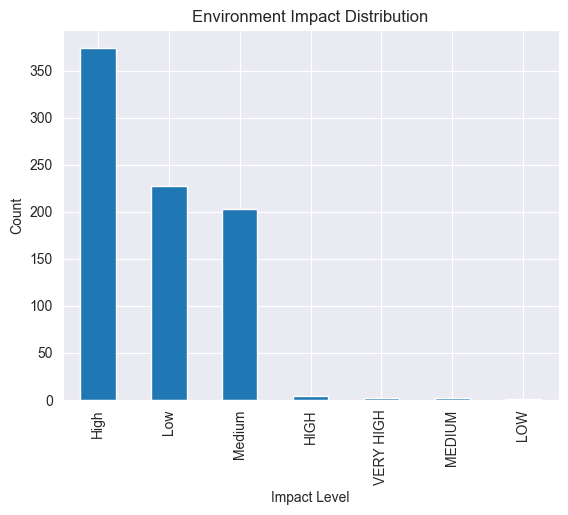

In [16]:
import matplotlib.pyplot as plt

df["Environment_Impact"].value_counts().plot(kind="bar")
plt.title("Environment Impact Distribution")
plt.xlabel("Impact Level")
plt.ylabel("Count")
plt.show()

Rocket Fuel Usage

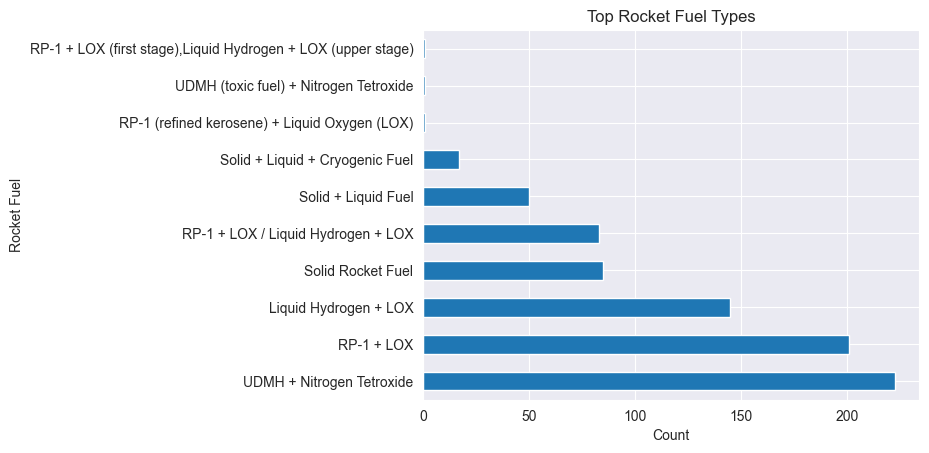

In [17]:
df["Rocket_Fuel"].value_counts().head(10).plot(kind="barh")
plt.title("Top Rocket Fuel Types")
plt.xlabel("Count")
plt.ylabel("Rocket Fuel")
plt.show()

#Mission Success vs Failure

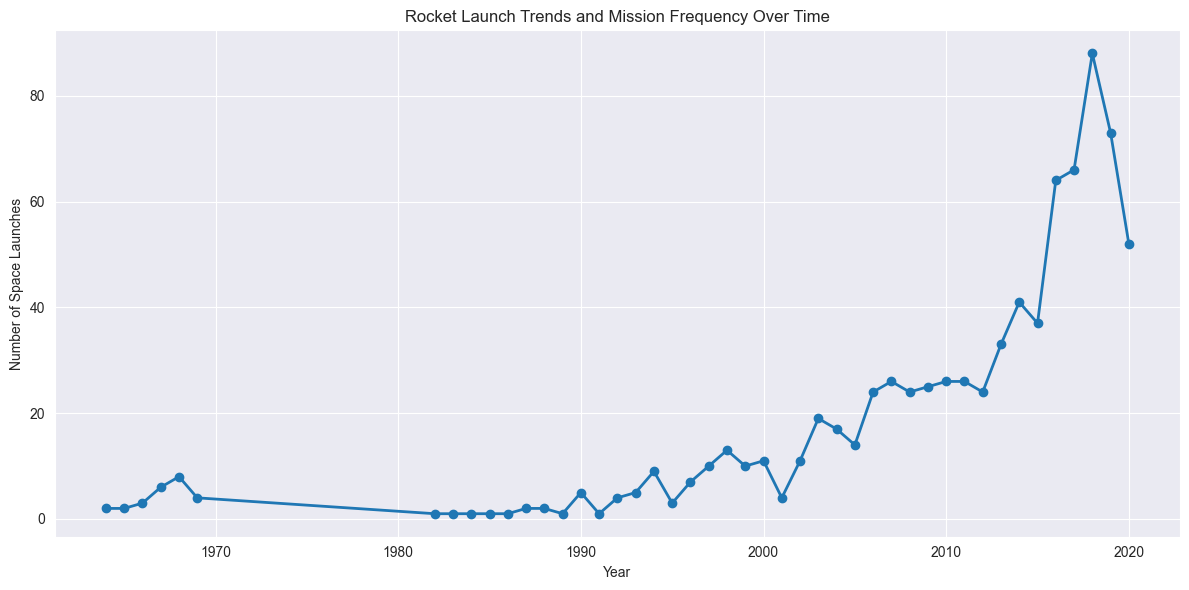

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# If Datum column exists, convert it into datetime
df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce", utc=True)

# Extract year from launch date
df["Year"] = df["Datum"].dt.year

# Count number of launches per year
launch_trend = df["Year"].value_counts().sort_index()

# Plot line chart
plt.figure(figsize=(12, 6))

plt.plot(
    launch_trend.index,
    launch_trend.values,
    marker="o",
    linewidth=2
)

plt.title("Rocket Launch Trends and Mission Frequency Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Space Launches")
plt.grid(True)

plt.tight_layout()
plt.show()

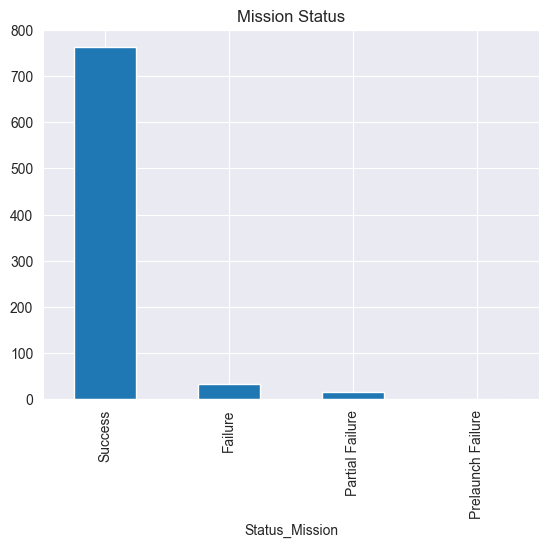

In [18]:
#Mission Success vs Failure
df["Status_Mission"].value_counts().plot(kind="bar")
plt.title("Mission Status")
plt.show()

Rocket Name + Company Name vs Cost

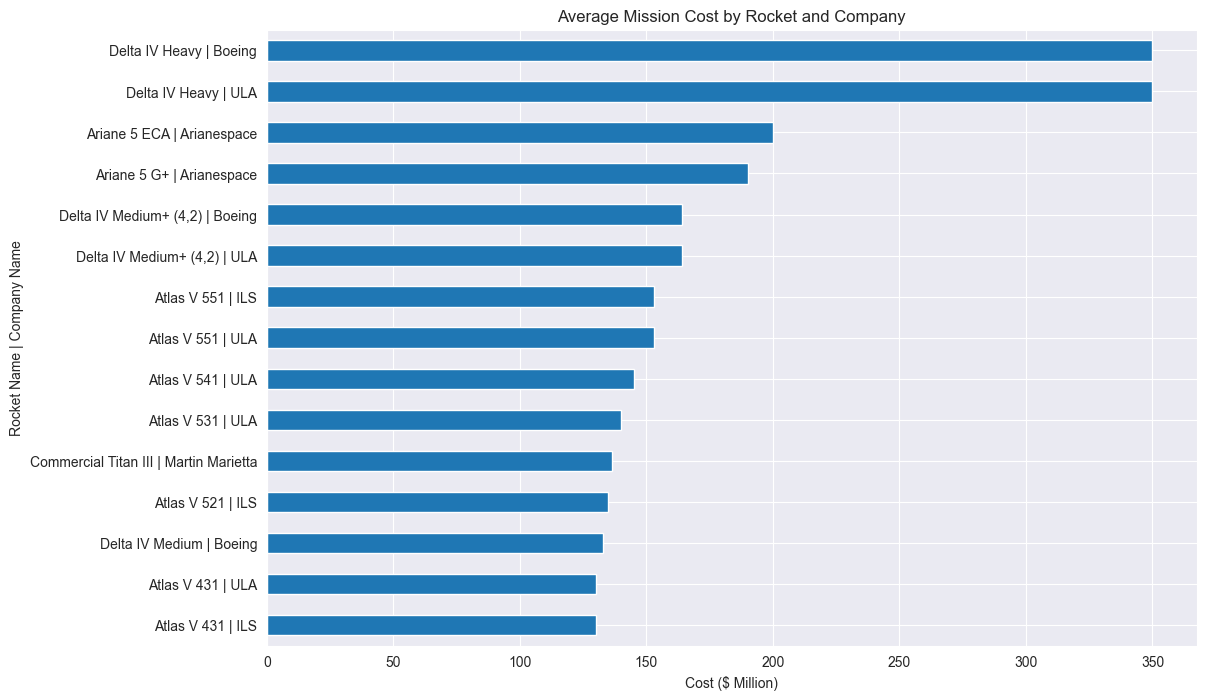

In [19]:
df["Rocket_Company"] = df["Rocket_Name"] + " | " + df["Company_Name"]

top_combo_cost = df.groupby("Rocket_Company")["Cost"].mean().sort_values(ascending=False).head(15)

top_combo_cost.sort_values().plot(kind="barh", figsize=(12, 8))

plt.title("Average Mission Cost by Rocket and Company")
plt.xlabel("Cost ($ Million)")
plt.ylabel("Rocket Name | Company Name")
plt.show()

Top 15 Rocket Name vs Cost

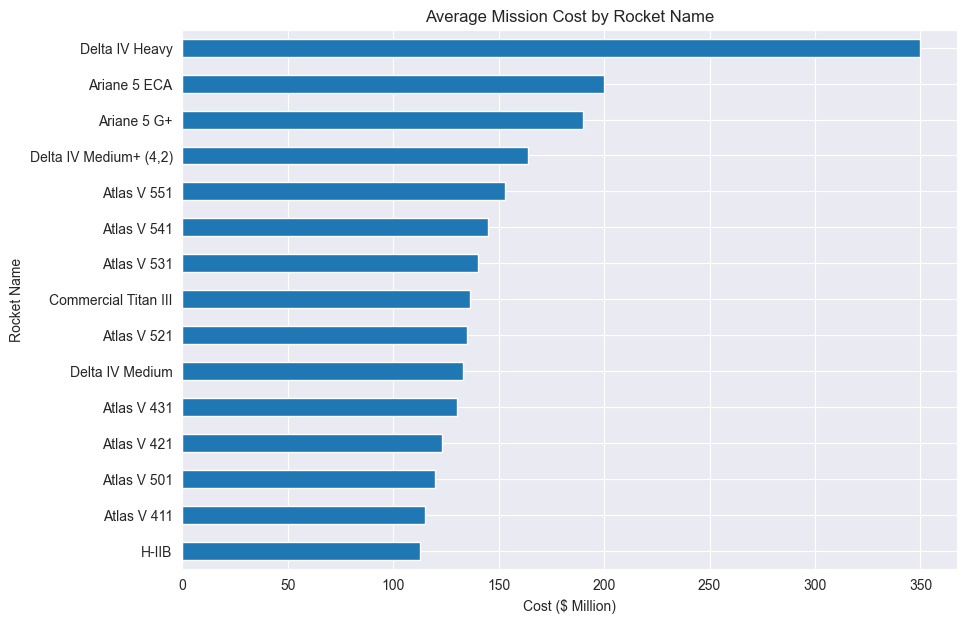

In [20]:
import matplotlib.pyplot as plt

top_rocket_cost = df.groupby("Rocket_Name")["Cost"].mean().sort_values(ascending=False).head(15)

top_rocket_cost.sort_values().plot(kind="barh", figsize=(10, 7))

plt.title("Average Mission Cost by Rocket Name")
plt.xlabel("Cost ($ Million)")
plt.ylabel("Rocket Name")
plt.show()

Top 15 Company Name vs Cost

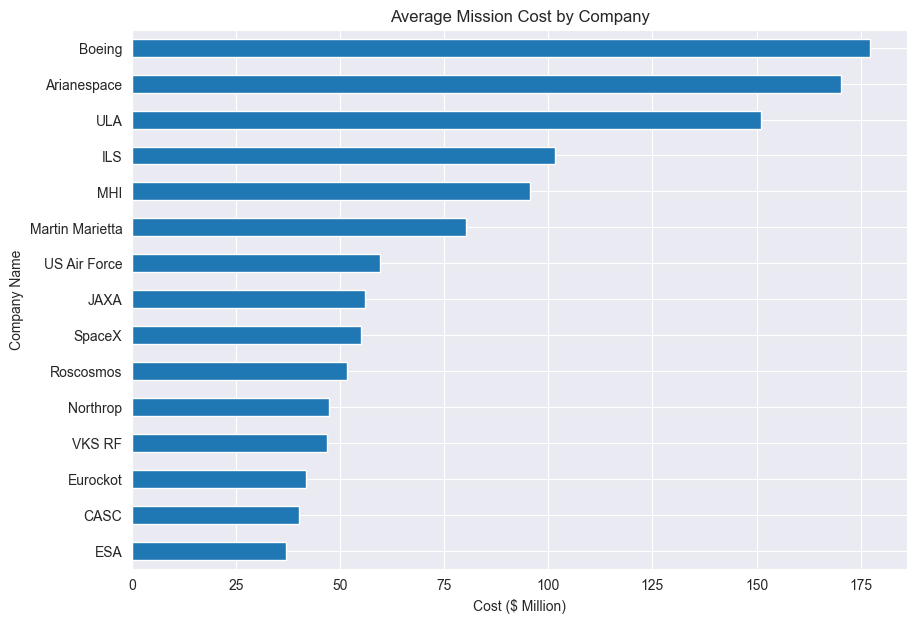

In [21]:
top_company_cost = df.groupby("Company_Name")["Cost"].mean().sort_values(ascending=False).head(15)

top_company_cost.sort_values().plot(kind="barh", figsize=(10, 7))

plt.title("Average Mission Cost by Company")
plt.xlabel("Cost ($ Million)")
plt.ylabel("Company Name")
plt.show()

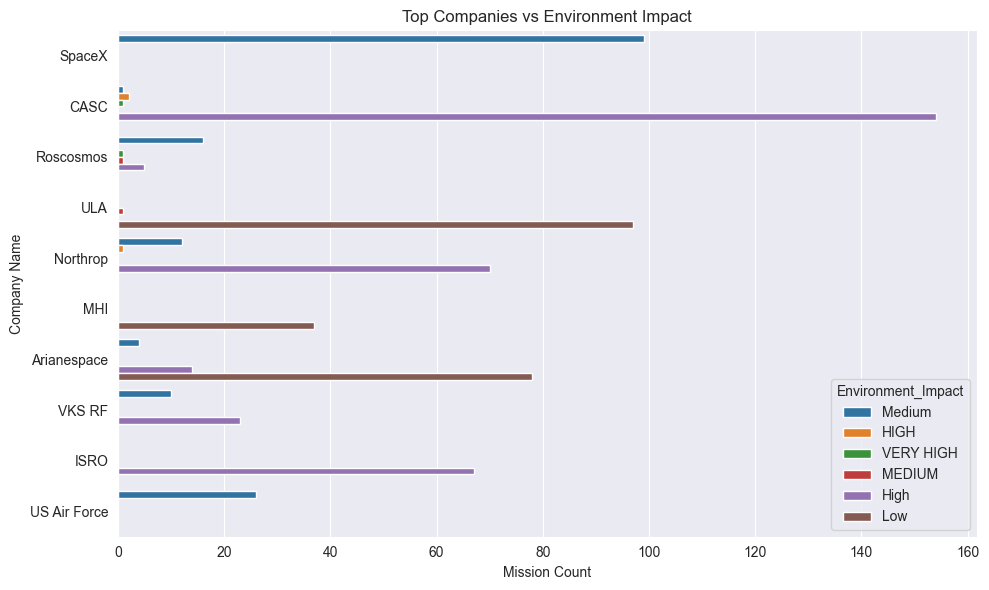

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_companies = df["Company_Name"].value_counts().head(10).index

plt.figure(figsize=(10, 6))

sns.countplot(
    y="Company_Name",
    hue="Environment_Impact",
    data=df[df["Company_Name"].isin(top_companies)]
)

plt.title("Top Companies vs Environment Impact")
plt.xlabel("Mission Count")
plt.ylabel("Company Name")

plt.tight_layout()
plt.show()

Accuracy: 0.8895705521472392

Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.96      0.90        76
         Low       0.98      0.96      0.97        48
      Medium       0.90      0.67      0.76        39

    accuracy                           0.89       163
   macro avg       0.90      0.86      0.88       163
weighted avg       0.89      0.89      0.89       163



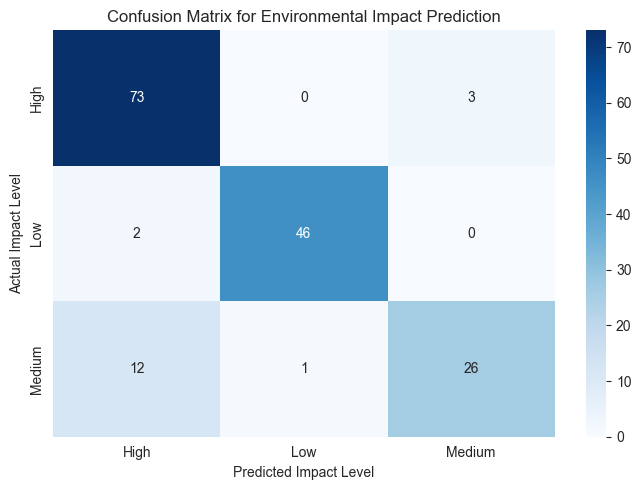

In [34]:
# =========================
# Confusion Matrix Analysis
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix for Environmental Impact Prediction")
plt.xlabel("Predicted Impact Level")
plt.ylabel("Actual Impact Level")

plt.tight_layout()
plt.show()

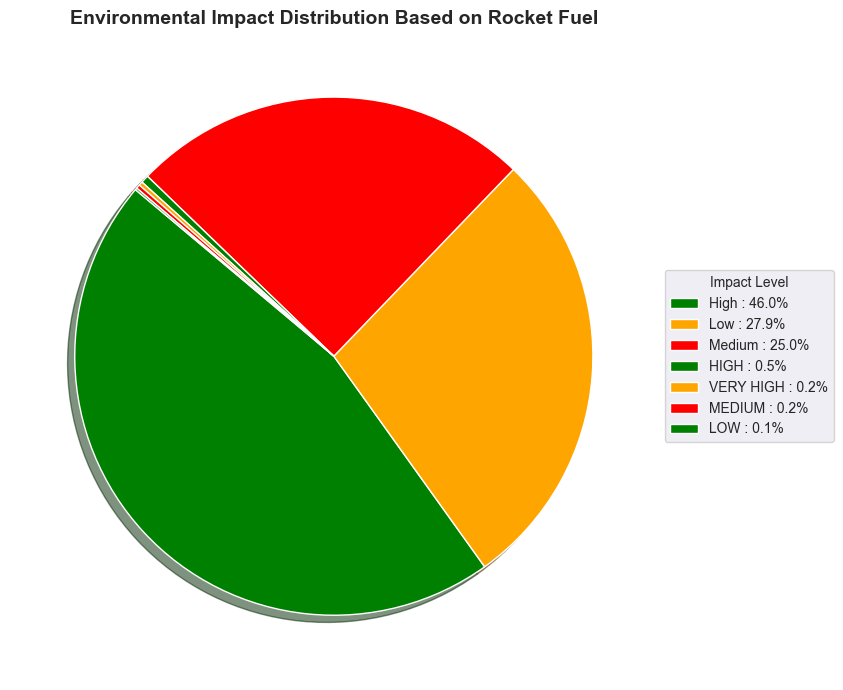

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Count impact categories
impact_counts = df["Environment_Impact"].value_counts()

# Colors
colors = ["green", "orange", "red"]

# Create figure
plt.figure(figsize=(9,7))

# Pie chart without text inside
wedges, texts = plt.pie(
    impact_counts,
    labels=None,
    startangle=140,
    colors=colors,
    shadow=True
)

# Create legend labels with percentages
legend_labels = [
    f"{label} : {round(value/sum(impact_counts)*100, 1)}%"
    for label, value in zip(impact_counts.index, impact_counts)
]

# Title
plt.title(
    "Environmental Impact Distribution Based on Rocket Fuel",
    fontsize=14,
    fontweight='bold'
)

# Legend box
plt.legend(
    wedges,
    legend_labels,
    title="Impact Level",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()

plt.show()

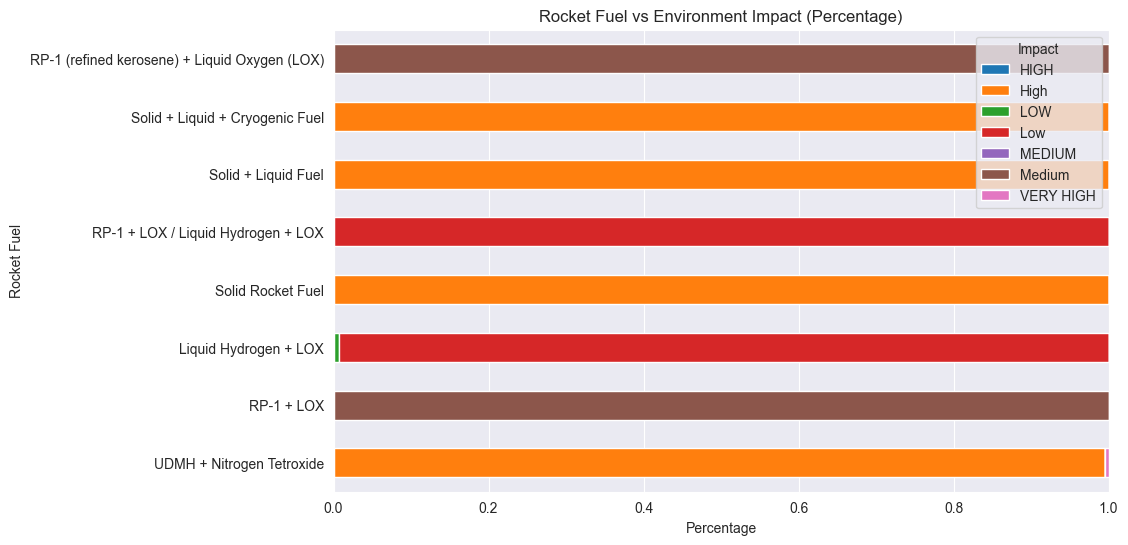

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Select top fuels (to avoid clutter)
top_fuels = df["Rocket_Fuel"].value_counts().head(8).index

# Create percentage table
fuel_impact = pd.crosstab(
    df["Rocket_Fuel"],
    df["Environment_Impact"],
    normalize="index"
)

# Plot
fuel_impact.loc[top_fuels].plot(
    kind="barh",
    stacked=True,
    figsize=(10,6)
)

plt.title("Rocket Fuel vs Environment Impact (Percentage)")
plt.xlabel("Percentage")
plt.ylabel("Rocket Fuel")
plt.legend(title="Impact")
plt.show()

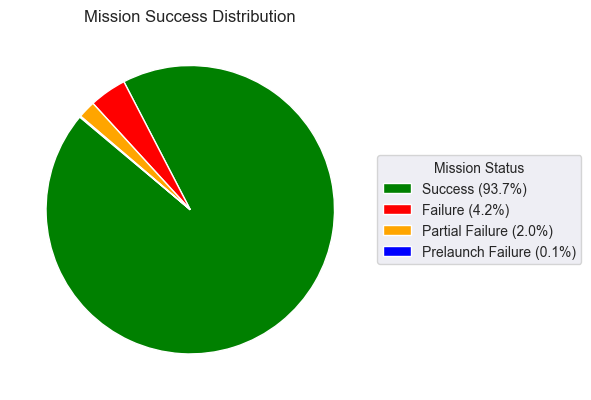

In [25]:
import matplotlib.pyplot as plt

counts = df["Status_Mission"].value_counts()

plt.figure(figsize=(6,6))

colors = ["green", "red", "orange", "blue"]

# Pie chart WITHOUT percentage text
plt.pie(
    counts,
    startangle=140,
    colors=colors[:len(counts)]
)

# Create labels with percentage
total = counts.sum()
labels = [
    f"{name} ({count/total*100:.1f}%)"
    for name, count in zip(counts.index, counts)
]

# Legend with percentage
plt.legend(
    labels,
    title="Mission Status",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Mission Success Distribution")
plt.tight_layout()
plt.show()

In [26]:
# ML MODEL: Predict Environment Impact
# =========================

import pandas as pd

## 1. Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r'[^A-Za-z0-9]+', '_', regex=True)
    .str.strip('_')
)

print("Available columns:")
print(df.columns.tolist())

# 2. Rename columns (Cost not needed now)
df.rename(columns={
    "Company_Name": "Company_Name",
    "Rocket_Name": "Rocket_Name",
    "Rocket_Fuel": "Rocket_Fuel",
    "Status_Mission": "Status_Mission",
    "Environment_Impact": "Environment_Impact"
}, inplace=True)

# 3. Extract Rocket_Name from Detail (IMPORTANT)
if "Rocket_Name" not in df.columns and "Detail" in df.columns:
    df["Rocket_Name"] = df["Detail"].astype(str).str.split("|").str[0].str.strip()

# 4. Select features (REMOVED COST)
features = ["Company_Name", "Rocket_Name", "Rocket_Fuel"]

# Target remains same
target = "Environment_Impact"

# 5. Check missing columns
missing_cols = [col for col in features + [target] if col not in df.columns]
print("Missing Columns:", missing_cols)

# 6. Create ML dataset
if len(missing_cols) > 0:
    print("Fix these missing columns first:", missing_cols)
else:
    df_ml = df[features + [target]].dropna()
    print("ML dataset created successfully")
    print(df_ml.head())

Available columns:
['Unnamed_0_1', 'Unnamed_0', 'Company_Name', 'Location', 'Datum', 'Detail', 'Status_Rocket', 'Cost', 'Status_Mission', 'Rocket_Fuel', 'Environment_Impact', 'Rocket_Name', 'Rocket_Company']
Missing Columns: []
ML dataset created successfully
  Company_Name       Rocket_Name  \
0       SpaceX  Falcon 9 Block 5   
1         CASC     Long March 2D   
3    Roscosmos   Proton-M/Briz-M   
4          ULA       Atlas V 541   
5         CASC     Long March 4B   

                                         Rocket_Fuel Environment_Impact  
0      RP-1 (refined kerosene) + Liquid Oxygen (LOX)             Medium  
1             UDMH (toxic fuel) + Nitrogen Tetroxide               HIGH  
3                          UDMH + Nitrogen Tetroxide          VERY HIGH  
4  RP-1 + LOX (first stage),Liquid Hydrogen + LOX...             MEDIUM  
5  UDMH (Unsymmetrical Dimethylhydrazine)\nNitrog...               HIGH  


In [27]:
#

In [28]:
# =========================
# R# =========================
# RANDOM FOREST MODEL
# Predict Environment Impact
# Error-free version
# =========================
# =========================
# RANDOM FOREST MODEL
# Predict Environment Impact
# =========================

import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------
# 1. Clean column names
# -------------------------
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r'[^A-Za-z0-9]+', '_', regex=True)
    .str.strip('_')
)

print("Available Columns:")
print(df.columns.tolist())

# -------------------------
# 2. Create Rocket_Name if missing
# -------------------------
if "Rocket_Name" not in df.columns:
    if "Detail" in df.columns:
        df["Rocket_Name"] = df["Detail"].astype(str).str.split("|").str[0].str.strip()
    else:
        raise KeyError("Rocket_Name and Detail columns are missing.")

# -------------------------
# 3. Select Features
# -------------------------
features = ["Company_Name", "Rocket_Name"]
target = "Environment_Impact"

missing_cols = [col for col in features + [target] if col not in df.columns]

if missing_cols:
    raise KeyError(f"Missing columns in dataset: {missing_cols}")

df[target] = df[target].astype(str).str.strip().str.title()

df[target] = df[target].replace({
    "Very High": "High"
})

df_model = df[features + [target]].dropna()

print("\nClass Distribution:")
print(df_model[target].value_counts())

X = df_model[features]
y = df_model[target]

# -------------------------
# 4. Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# -------------------------
# 5. Preprocessing
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features)
    ]
)

# -------------------------
# 6. Random Forest Model
# -------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42,
        class_weight="balanced"
    ))
])

# -------------------------
# 7. Train Model
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# 8. Prediction
# -------------------------
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# -------------------------
# 9. Accuracy
# -------------------------
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

if train_acc - test_acc > 0.1:
    print("⚠️ Model is Overfitting")
else:
    print("✅ Model is Generalizing Well")

# -------------------------
# 10. Classification Report
# -------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

# -------------------------
# 11. Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print(cm)

# -------------------------
# 12. Cross Validation
# -------------------------
cv_folds = min(5, len(df_model))

if cv_folds >= 2:
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=cv)

    print("\nCross Validation Scores:", cv_scores)
    print("Average CV Accuracy:", cv_scores.mean())
else:
    print("\nCross Validation skipped: not enough data.")



Available Columns:
['Unnamed_0_1', 'Unnamed_0', 'Company_Name', 'Location', 'Datum', 'Detail', 'Status_Rocket', 'Cost', 'Status_Mission', 'Rocket_Fuel', 'Environment_Impact', 'Rocket_Name', 'Rocket_Company']

Class Distribution:
Environment_Impact
High      380
Low       228
Medium    205
Name: count, dtype: int64

Train Accuracy: 0.9261538461538461
Test Accuracy: 0.8895705521472392
✅ Model is Generalizing Well

Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.96      0.90        76
         Low       0.98      0.96      0.97        48
      Medium       0.90      0.67      0.76        39

    accuracy                           0.89       163
   macro avg       0.90      0.86      0.88       163
weighted avg       0.89      0.89      0.89       163


Confusion Matrix:
[[73  0  3]
 [ 2 46  0]
 [12  1 26]]

Cross Validation Scores: [0.90797546 0.90797546 0.92638037 0.88888889 0.95679012]
Average CV Accuracy: 0.9176020601378474


In [29]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# =========================
# DROPDOWN OPTIONS
# =========================

company_options = sorted(df["Company_Name"].dropna().unique())
rocket_options = sorted(df["Rocket_Name"].dropna().unique())
fuel_options = sorted(df["Rocket_Fuel"].dropna().unique())

# =========================
# TITLE
# =========================

title = widgets.HTML("""
<h2 style='color:#0b5394;'>
🚀 Rocket Environmental Impact Predictor
</h2>

<p>Select rocket details and click Predict.</p>
""")

# =========================
# DROPDOWNS
# =========================

company_dropdown = widgets.Dropdown(
    options=company_options,
    description="Company:",
    layout=widgets.Layout(width="700px")
)

rocket_dropdown = widgets.Dropdown(
    options=rocket_options,
    description="Rocket:",
    layout=widgets.Layout(width="700px")
)

fuel_dropdown = widgets.Dropdown(
    options=fuel_options,
    description="Fuel:",
    layout=widgets.Layout(width="700px")
)

# =========================
# BUTTON
# =========================

predict_button = widgets.Button(
    description="🌍 Predict Impact",
    button_style="success",
    layout=widgets.Layout(width="300px", height="50px")
)

# =========================
# OUTPUT AREA
# =========================

output = widgets.Output()

# =========================
# PREDICTION FUNCTION
# =========================

def predict_impact(button):

    output.clear_output()

    with output:

        print("Prediction Running...")

        try:

            # Input dataframe
            new_rocket = pd.DataFrame([{
                "Company_Name": company_dropdown.value,
                "Rocket_Name": rocket_dropdown.value,
                "Rocket_Fuel": fuel_dropdown.value
            }])

            # Prediction
            prediction = model.predict(new_rocket)[0]

            # Probability
            probability = model.predict_proba(new_rocket)[0]

            # Color
            color = {
                "Low": "green",
                "Medium": "orange",
                "High": "red"
            }.get(prediction, "blue")

            # Show details
            display(HTML("<hr>"))

            display(HTML("""
            <h3>✅ Selected Rocket Details</h3>
            """))

            display(new_rocket)

            # Prediction result
            display(HTML(f"""
            <h2 style='color:{color};'>
            Predicted Environmental Impact: {prediction}
            </h2>
            """))

            # Probability section
            display(HTML("<h3>Prediction Probability</h3>"))

            for impact, prob in zip(model.classes_, probability):
                print(f"{impact}: {round(prob * 100, 2)}%")

        except Exception as e:

            print("ERROR FOUND:")
            print(e)

# =========================
# CONNECT BUTTON
# =========================

predict_button.on_click(predict_impact)

# =========================
# FINAL UI
# =========================

ui = widgets.VBox([
    title,
    company_dropdown,
    rocket_dropdown,
    fuel_dropdown,
    predict_button,
    output
])

display(ui)

In [30]:
# Check prediction for all company + rocket combinations
results = []

for company in company_options:
    for rocket in rocket_options:
        new_data = pd.DataFrame([{
            "Company_Name": company,
            "Rocket_Name": rocket
        }])

        pred = model.predict(new_data)[0]
        prob = model.predict_proba(new_data)[0].max()

        results.append({
            "Company_Name": company,
            "Rocket_Name": rocket,
            "Predicted_Impact": pred,
            "Confidence": round(prob * 100, 2)
        })

prediction_df = pd.DataFrame(results)

# Show Low predictions
print("LOW IMPACT ROCKETS")
display(prediction_df[prediction_df["Predicted_Impact"] == "Low"].head(20))

# Show Medium predictions
print("MEDIUM IMPACT ROCKETS")
display(prediction_df[prediction_df["Predicted_Impact"] == "Medium"].head(20))

# Show High predictions
print("HIGH IMPACT ROCKETS")
display(prediction_df[prediction_df["Predicted_Impact"] == "High"].head(20))

LOW IMPACT ROCKETS


,Company_Name,Rocket_Name,Predicted_Impact,Confidence
0,Arianespace,Antares 110,Low,42.83
1,Arianespace,Antares 120,Low,42.83
2,Arianespace,Antares 130,Low,42.83
3,Arianespace,Antares 230,Low,42.83
4,Arianespace,Antares 230+,Low,42.83
5,Arianespace,Ariane 5 ECA,Low,60.68
6,Arianespace,Ariane 5 G+,Low,42.83
7,Arianespace,Atlas V 401,Low,47.79
8,Arianespace,Atlas V 411,Low,43.42
9,Arianespace,Atlas V 421,Low,43.46


MEDIUM IMPACT ROCKETS


,Company_Name,Rocket_Name,Predicted_Impact,Confidence
28,Arianespace,Falcon 9 Block 5,Medium,41.13
98,Boeing,Electron/Curie,Medium,37.62
101,Boeing,Falcon 9 Block 3,Medium,39.17
102,Boeing,Falcon 9 Block 4,Medium,36.27
103,Boeing,Falcon 9 Block 5,Medium,47.45
105,Boeing,Falcon 9 v1.1,Medium,35.79
139,Boeing,Soyuz 2.1a,Medium,39.93
148,Boeing,Titan IIIB,Medium,36.62
248,EER,Electron/Curie,Medium,37.62
251,EER,Falcon 9 Block 3,Medium,39.17


HIGH IMPACT ROCKETS


,Company_Name,Rocket_Name,Predicted_Impact,Confidence
74,Arianespace,Vega,High,42.51
75,Boeing,Antares 110,High,36.88
76,Boeing,Antares 120,High,36.88
77,Boeing,Antares 130,High,36.88
78,Boeing,Antares 230,High,36.88
79,Boeing,Antares 230+,High,36.88
81,Boeing,Ariane 5 G+,High,36.88
83,Boeing,Atlas V 411,High,36.47
84,Boeing,Atlas V 421,High,36.72
85,Boeing,Atlas V 431,High,36.88


In [31]:
df["Environment_Impact"].value_counts()

Environment_Impact
High      380
Low       228
Medium    205
Name: count, dtype: int64

In [32]:
# =========================
# FAST FIND LOW IMPACT SELECTIONS
# =========================

# Only real combinations from dataset
test_df = df[[
    "Company_Name",
    "Rocket_Name",
    "Rocket_Fuel"
]].dropna().drop_duplicates()

# Predict all rows at once
predictions = model.predict(test_df)
probabilities = model.predict_proba(test_df).max(axis=1)

# Add results
test_df["Predicted_Impact"] = predictions
test_df["Confidence"] = (probabilities * 100).round(2)

# Filter Low impact
low_df = test_df[test_df["Predicted_Impact"] == "Low"]

print("Total Low Impact Combinations:", len(low_df))

display(low_df.head(30))

Total Low Impact Combinations: 19


,Company_Name,Rocket_Name,Rocket_Fuel,Predicted_Impact,Confidence
4,ULA,Atlas V 541,"RP-1 + LOX (first stage),Liquid Hydrogen + LOX...",Low,58.13
9,JAXA,H-IIA 202,Liquid Hydrogen + LOX,Low,40.86
29,MHI,H-IIB,Liquid Hydrogen + LOX,Low,39.74
30,ULA,Atlas V 501,RP-1 + LOX / Liquid Hydrogen + LOX,Low,59.06
38,ULA,Atlas V 551,RP-1 + LOX / Liquid Hydrogen + LOX,Low,59.57
40,Arianespace,Soyuz 2.1b/Fregat,RP-1 + LOX,Low,42.10
48,Arianespace,Ariane 5 ECA,Liquid Hydrogen + LOX,Low,60.68
51,ULA,Atlas V 411,RP-1 + LOX / Liquid Hydrogen + LOX,Low,58.99
53,MHI,H-IIA 202,Liquid Hydrogen + LOX,Low,50.26
107,ULA,"Delta IV Medium+ (4,2)",Liquid Hydrogen + LOX,Low,59.75
